Stochastic Prior - Wan+24 regulator model. 
$\sigma_{\text reg}$ = amplitude of long-timescale SFR fluctuations
$\tau_{\text eq}$ = gas-regulations equilibrium timescale
$\tau_{\text in}$ = inflow correlation timescale
$\sigma_{\text dyn}$ = amplitude of short-timescale bursts (GMC/dynamical)
$\tau_{\text dyn}$ = their correlation timescale

# Emission Lines

For emission line galaxies: emission lines trace < 10 Myr SFR -> strong H $\alpha$ EW needs recent SFR $\gtrsim$ long-term average, so high $\sigma_{\text dyn}$ (large bursts) and/or short $\tau_{\rm dyn}$ matters most; $\sigma_{\rm reg}$ with short $\tau_{\text eq}$ also boosts burst duty cycle.

The Wan+24 paper in S5 finds that Prospector constraints only $\sigma_{\text reg}$ while $\tau_{\text eq}$, $\sigma_{\text dyn}$, $\tau_{\text dyn}$ come out prior-dominated. So, we could kill the uncontrainable dyn component and let the $\sigma_{\text reg}$ carry all the burst variance.

In [1]:
# draw N SFH from our current prior vs Iyer's config (sigma_dyn=0, sigma_reg only tau_eq > tau_in)
# compute sSFR_5Myr / sSFR_100Myr (burst ratio ~~ Halpha EW)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hubersed.prospector.utils import make_stochastic_agebins, universe_age_gyr
# Iyer's GP-SFH code - exact ACF kernel from Wan+24 Eq 4
from prospect.models.hyperparam_transforms import extended_regulator_model_kernel_paramlist


rng = np.random.default_rng(42)
N = 5000
Z = 0.2  # typical BGS redshift
T_H = universe_age_gyr(Z)

agebins = make_stochastic_agebins(Z)          # (10, 2) log10(yr)
bincenters_gyr = 10 ** agebins.mean(axis=1) / 1e9
dt_yr = np.diff(10 ** agebins, axis=1).ravel()  # bin widths in yr
dtau = bincenters_gyr[:, None] - bincenters_gyr[None, :]


def draw_sfhs(psd_params, rng):
    """psd_params: (N, 5) [sigma_reg, tau_eq, tau_in, sigma_dyn, tau_dyn].
    Returns (N, 10) log SFR (mean 0, flat baseline) over agebins."""
    out = np.empty((len(psd_params), len(bincenters_gyr)))
    for i, p in enumerate(psd_params):
        cov = extended_regulator_model_kernel_paramlist(dtau, p)
        cov += 1e-10 * np.eye(cov.shape[0])
        out[i] = rng.multivariate_normal(np.zeros(cov.shape[0]), cov, method="cholesky")
    return out


def burst_ratio(logsfr):
    """SFR(1-10 Myr) / SFR(<100 Myr), mass-weighted over the agebins."""
    sfr = 10 ** logsfr
    mass = sfr * dt_yr                      # mass formed per bin
    young = 10 ** agebins[:, 1] <= 1e7      # bins fully within 10 Myr
    m100 = 10 ** agebins[:, 1] <= 1e8       # bins fully within 100 Myr
    sfr10 = mass[:, young].sum(axis=1) / dt_yr[young].sum()
    sfr100 = mass[:, m100].sum(axis=1) / dt_yr[m100].sum()
    return sfr10 / sfr100

/Users/ng27753/Astronomy_Research/hubersed/.venv/lib/python3.13/site-packages/prospect/sources/fake_fsps.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [3]:
# current prior (config.py get_priors): sigma_reg logU(0.1,5), tau_eq U(0.01,t_H),
# tau_in U(0.01,t_H), sigma_dyn logU(0.001,0.5), tau_dyn truncN(0.01,0.02,[0.005,0.2])
from hubersed.distributions import sample_truncated_normal, sample_log_uniform, sample_uniform

cur = np.column_stack([
    sample_log_uniform(0.1, 5, size=N, rng=rng),
    sample_uniform(0.01, T_H, size=N, rng=rng),
    sample_uniform(0.01, T_H, size=N, rng=rng),
    sample_log_uniform(0.001, 0.5, size=N, rng=rng),
    sample_truncated_normal(0.01, 0.02, 0.005, 0.2, size=N, rng=rng),
])

# Iyer config: sigma_reg only, sigma_dyn = 0, tau_dyn = 1 (inert), tau_eq > tau_in
tau_eq_iyer = sample_uniform(0.01, T_H, size=N, rng=rng)
iyer = np.column_stack([
    sample_log_uniform(0.1, 5, size=N, rng=rng),
    tau_eq_iyer,
    sample_uniform(0.01, tau_eq_iyer, size=N, rng=rng),  # tau_in < tau_eq
    np.zeros(N),
    np.ones(N),
])

logsfr_cur = draw_sfhs(cur, rng)
logsfr_iyer = draw_sfhs(iyer, rng)
br_cur = burst_ratio(logsfr_cur)
br_iyer = burst_ratio(logsfr_iyer)

current: log burst ratio p16/50/84 = -0.03/-0.00/0.04, p99 = 0.35, p99.9 = 0.56
iyer: log burst ratio p16/50/84 = -0.01/0.00/0.01, p99 = 0.14, p99.9 = 0.45


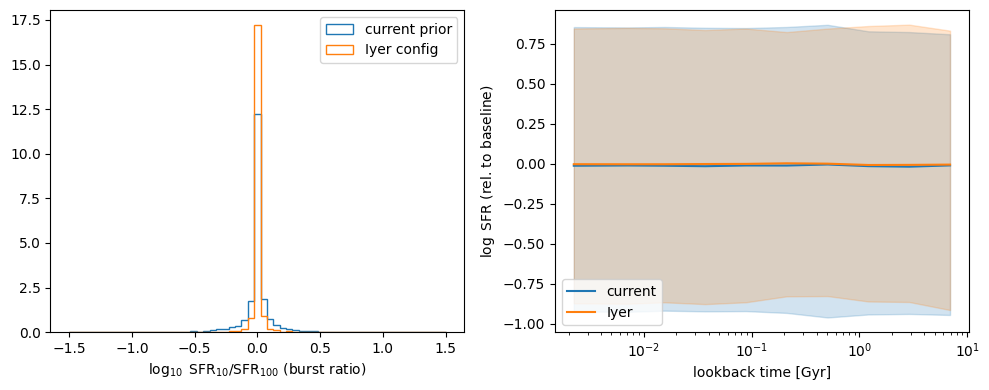

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bins = np.linspace(-1.5, 1.5, 60)
axes[0].hist(np.log10(br_cur), bins=bins, histtype="step", label="current prior", density=True)
axes[0].hist(np.log10(br_iyer), bins=bins, histtype="step", label="Iyer config", density=True)
axes[0].set_xlabel(r"$\log_{10}$ SFR$_{10}$/SFR$_{100}$ (burst ratio)")
axes[0].legend()

for logsfr, c, lab in [(logsfr_cur, "C0", "current"), (logsfr_iyer, "C1", "Iyer")]:
    lo, med, hi = np.percentile(logsfr, [16, 50, 84], axis=0)
    axes[1].fill_between(bincenters_gyr, lo, hi, color=c, alpha=0.2)
    axes[1].plot(bincenters_gyr, med, c, label=lab)
axes[1].set_xscale("log")
axes[1].set_xlabel("lookback time [Gyr]")
axes[1].set_ylabel(r"$\log$ SFR (rel. to baseline)")
axes[1].legend()
plt.tight_layout()

for name, br in [("current", br_cur), ("iyer", br_iyer)]:
    q = np.percentile(np.log10(br), [16, 50, 84, 99, 99.9])
    print(f"{name}: log burst ratio p16/50/84 = {q[0]:.2f}/{q[1]:.2f}/{q[2]:.2f}, p99 = {q[3]:.2f}, p99.9 = {q[4]:.2f}")


# My prior rarely exceeds ~3x brust enhancement, while Iyer's can

In [5]:
# now that we know that iyer's config can produce more extreme burst ratios, we can
# first check the Ha EW distribution of my 500k mocks and then compare to the Ha EW of the FastSpecFit VAC
# of the emission line outliers.

In [6]:
# Mock Ha EW: from the WIDE library h5 (LS6, Aug 25) — line_lum is stored
# (Lsun/Msun formed, dust-attenuated; verified in prospect galaxy_basis.py).
# EW_rest = L_Ha / C_lambda_rest, continuum from line-free side windows of the
# noiseless mock spectrum. Extracted on LS6 -> results/mock_ha_ew_wide.npz.
from astropy.io import fits

mock = np.load("../results/mock_ha_ew_wide.npz")
ew_mock = mock["ew_ha_rest"]
ew_mock = ew_mock[np.isfinite(ew_mock) & (ew_mock > 0)]

# outlier Ha EW from FastSpecFit VAC, emission-class full-branch outliers
out = np.load("../results/outliers310_sample.npz", allow_pickle=True)
sel = (out["source_class"] == "emission") & (out["branch"] != "cont-only")
tids = out["target_ids"][sel]
with fits.open("../data/fastspec-iron-sv3-bright.fits") as h:
    vac_tid = h[1].data["TARGETID"]
    vac_ew = h[1].data["HALPHA_EW"]
i = {t: j for j, t in enumerate(vac_tid)}
ew_out = np.array([vac_ew[i[t]] for t in tids if t in i])
ew_out = ew_out[ew_out > 0]
print(f"mocks: {ew_mock.size}, emission outliers: {ew_out.size}")

mocks: 428178, emission outliers: 218


mock EW p50/p84/p99/p99.9 = 46/117/471/1016 A
outlier EW p16/p50/p84 = 97/145/247 A
outliers beyond mock p99: 2%, beyond p99.9: 0%


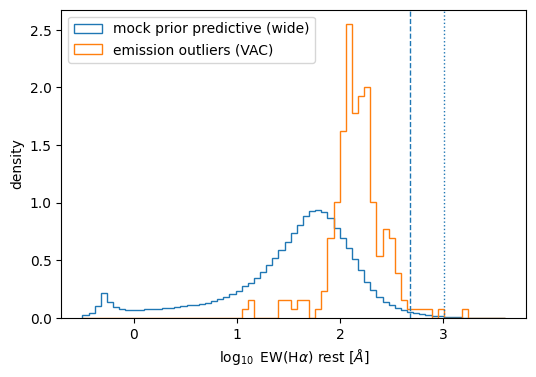

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(-0.5, 3.6, 70)
ax.hist(np.log10(ew_mock), bins=bins, density=True, histtype="step", label="mock prior predictive (wide)")
ax.hist(np.log10(ew_out), bins=bins, density=True, histtype="step", label="emission outliers (VAC)")
for p, ls in [(99, "--"), (99.9, ":")]:
    ax.axvline(np.log10(np.percentile(ew_mock, p)), color="C0", ls=ls, lw=1)
ax.set_xlabel(r"$\log_{10}$ EW(H$\alpha$) rest [$\AA$]")
ax.set_ylabel("density")
ax.legend()

pm = np.percentile(ew_mock, [50, 84, 99, 99.9])
po = np.percentile(ew_out, [16, 50, 84])
frac_beyond = (ew_out > pm[2]).mean(), (ew_out > pm[3]).mean()
print(f"mock EW p50/p84/p99/p99.9 = {pm[0]:.0f}/{pm[1]:.0f}/{pm[2]:.0f}/{pm[3]:.0f} A")
print(f"outlier EW p16/p50/p84 = {po[0]:.0f}/{po[1]:.0f}/{po[2]:.0f} A")
print(f"outliers beyond mock p99: {100*frac_beyond[0]:.0f}%, beyond p99.9: {100*frac_beyond[1]:.0f}%")

# Continuum Outliers

For the continuum outliers, the light integrates over Gyr so only long timescale piece matters: $\sigma_{\text reg}$ broadens and even multi modalises the mass-weighted-age prior.

at large $\sigma_{\text reg}$ and $t_{\text age}$ prior histogram develops distinct peaks which is an artifact of the 10-bin SFH: a big fluctuation tends to dump most of the mass into one bin (whose width ~ $\tau_{\text eq} / \tau_{\text in}$), so $t_{\text age}$ piles up at discrete values near individual bin centers instead of spreading smoothly.

Wan+24 quiescent appendix shows that the stochastic priors hits an sSFR floor (~1e-11.4 yr^-1) and biases logZ high by 0.14dex...

Things to check these against: Dn4000, HDelta_A (burst memory ~1 Gyr), Mg b + Fe5270/5335 (metallicity, alpha-enhancement), NaD, G-band, TiO bands, overall continuum slope/color, and sigma*

Dn4000 + Hdelta_A trace age/burst history (SFH-prior territory)l Mg b/Fe are chemistry so limitations are abundance patterns (fixed alpha, solar scaled MIST)

We can do a joint Dn4000-Hdelta_A plane since Dn400 tracks light-weighted age montonically,, Hdelta_A breaks the degenecray between smooth decline and recent burst, which is extact sigma_reg/burst-history part the stochastic prior controls

mocks finite: 500000, continuum outliers: 34, weak-em: 25


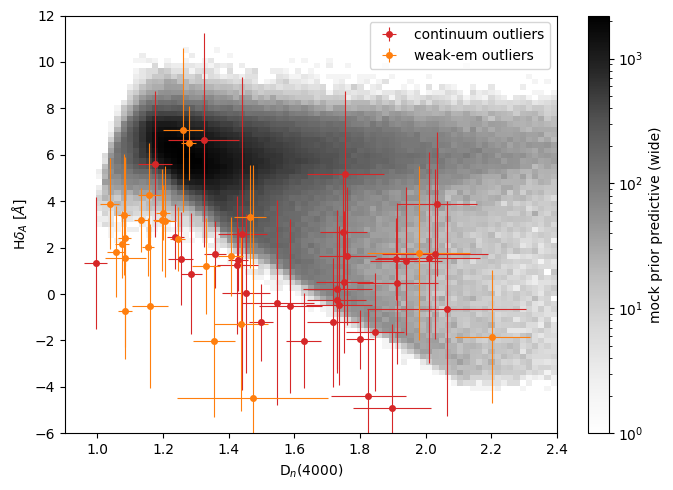

In [8]:
# Dn4000 (Balogh+1999, F_nu ratio) + Hdelta_A (Worthey & Ottaviani 1997), same
# definitions as Iyer+2022 S3.3, measured with the SAME code both sides
# (bin/prospector/measure_indices.py on LS6):
#   mocks    = wide-library noiseless spectra, injected emission lines subtracted
#              analytically (line_lum, sigma_gas (+) DESI LSF)
#   outliers = DESI spectra, FastSpecFit line models subtracted, ivar-weighted,
#              propagated errors
mi = np.load("../results/mock_indices_wide.npz")
oi = np.load("../results/outlier310_indices.npz", allow_pickle=True)

mok = np.isfinite(mi["dn4000"]) & np.isfinite(mi["hdelta_a"])
cont_sel = oi["source_class"] == "continuum"
weak_sel = oi["source_class"] == "weak-em"
print(f"mocks finite: {mok.sum()}, continuum outliers: {cont_sel.sum()}, weak-em: {weak_sel.sum()}")

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(mi["dn4000"][mok], mi["hdelta_a"][mok], bins=[np.linspace(0.9, 2.4, 80),
              np.linspace(-6, 12, 80)], cmap="Greys", norm=plt.matplotlib.colors.LogNorm())
for sel, c, lab in [(cont_sel, "C3", "continuum outliers"), (weak_sel, "C1", "weak-em outliers")]:
    ax.errorbar(oi["dn4000"][sel], oi["hdelta_a"][sel], xerr=oi["dn4000_err"][sel],
                yerr=oi["hdelta_a_err"][sel], fmt="o", ms=4, color=c, lw=0.8, label=lab)
ax.set_xlabel(r"D$_n$(4000)")
ax.set_ylabel(r"H$\delta_A$ [$\AA$]")
ax.legend()
plt.colorbar(h[3], ax=ax, label="mock prior predictive (wide)")
plt.tight_layout()

In [9]:
# coverage: fraction of outliers outside the mock 99% / 99.9% contour, via
# 2D KDE-free approach — rank each outlier's local mock density percentile
from scipy.stats import gaussian_kde

sub = np.random.default_rng(0).choice(np.where(mok)[0], 50000, replace=False)
kde = gaussian_kde(np.vstack([mi["dn4000"][sub], mi["hdelta_a"][sub]]))
dens_mock = kde(np.vstack([mi["dn4000"][sub[:5000]], mi["hdelta_a"][sub[:5000]]]))

for sel, lab in [(cont_sel, "continuum"), (weak_sel, "weak-em")]:
    ok = np.isfinite(oi["dn4000"][sel]) & np.isfinite(oi["hdelta_a"][sel])
    d = kde(np.vstack([oi["dn4000"][sel][ok], oi["hdelta_a"][sel][ok]]))
    pct = np.array([(dens_mock < di).mean() for di in d])  # density rank
    out99 = (pct < 0.01).sum(); out999 = (pct < 0.001).sum()
    print(f"{lab}: n={ok.sum()}, below mock 1% density: {out99}, below 0.1%: {out999}")

continuum: n=34, below mock 1% density: 13, below 0.1%: 9
weak-em: n=25, below mock 1% density: 12, below 0.1%: 10


Outliers are almost all below the mock locus: too-weak Helta_A at fixed Dn4000. There are two clumps.
1. Dn4000 ≈ 1.0–1.4 with Hδ_A ≈ −2 to +2 where mocks predict 4–8 Å — young-looking continuum with missing A-star absorption
2.  Dn4000 ≈ 1.7–2.1, Hδ_A ≈ −5 to +2, brushing the sparse old-population tail.


Weak absorption at given break has two causes one physical and one could be systematic: continuum dilution (a featureless non-stellar component — AGN-like — filling in absorption lines and weakening the break simultaneously, dragging points down-left), or under-subtracted Hdelta emission infill....

A coherent, population level Hdelta_A deficit at fixed Dn4000  that is not infill, not dilution, not obviously sigma*, the light has a normal break and normal metal lines but weaker Balmer absorption than any SFH the prior produces. So the remiaining suspects are  real SPS/abundance systematics in the Balmer-line region, or SFH shapes outside the stochastic family (e.g., old-dominated light with a thin young frosting suppressing the A-star phase contribution).

 the high-Dn4000 clump (1.7–2.1) has a viable, literature-backed mechanism — CN contamination from super-solar C/N (established for massive ETGs by Conroy+14) — i.e., a stellar-abundance model limitation, separate from and additive to the nebular fixed-N/O issue already in the paper narrative. The low-Dn4000 clump is not explained by CN (young light-weighted ages lack CN-strong giants) — that one stays open; candidate explanations remain SFH-shape coverage or something else, and the MAP residuals at Hδ (fits at 21/310) are the next discriminator. Also worth noting: this makes a clean falsifiable check — CN-sensitive index (e.g., CN4216 or Ca4227 vs Ca4227_r) should be enhanced in the high-Dn4000 outliers if the story is right.

Low-Dn4000 clump: controls showed most of the raw deficit is a survey-wide systematic (aperture + b-arm calibration), but outlier-specific excess survives (MW p<0.001). Mechanism audit (see knowledge/low_dn4000_weak_hdelta_mechanisms.md): continuous-SFH locus and nebular continuum and CN all ruled out; leading candidate = **recently-quenched burst** (ended 10–50 Myr ago): Gonzalez-Delgado+1999 (papers/astro-ph_9907116) shows Balmer EW is flat at ~3 Å below 4 Myr and peaks (11–16 Å) only at ~500 Myr (A2V turnoff), so the post-nebular/pre-A-star window gives weak Hδ_A + low Dn4000 + weak emission. Test below: does the prior populate that window? SFR-ratio plane (nonparametric-SFH log-SFR-ratio diagnostic): quenched-burst corner holds **0.34%** of draws (quench alone 1.2%) — thin tail, same order as the 0.1% outlier threshold: undersampled, not absent.

quench alone (y < -log3): 1.21%
quenched burst corner (x > log3 & y < -log3): 0.340% (68 of 20000)


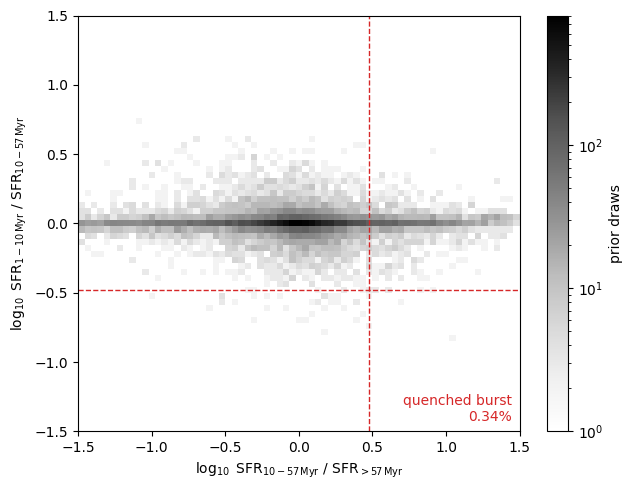

In [10]:
# quenched-burst window coverage: SFR-ratio plane of 20k prior draws
# bins (z=0.2): 0-1 = 1-10 Myr (ionizing), 2-3 = 10-57 Myr (post-nebular,
# pre-A-star), 4+ = >57 Myr
N2 = 20000
rng2 = np.random.default_rng(42)
P = np.column_stack([
    sample_log_uniform(0.1, 5, size=N2, rng=rng2),
    sample_uniform(0.01, T_H, size=N2, rng=rng2),
    sample_uniform(0.01, T_H, size=N2, rng=rng2),
    sample_log_uniform(0.001, 0.5, size=N2, rng=rng2),
    sample_truncated_normal(0.01, 0.02, 0.005, 0.2, size=N2, rng=rng2),
])
ls = draw_sfhs(P, rng2)
sfr = 10 ** ls
s010 = (sfr[:, :2] * dt_yr[:2]).sum(1) / dt_yr[:2].sum()
s1050 = (sfr[:, 2:4] * dt_yr[2:4]).sum(1) / dt_yr[2:4].sum()
s_old = (sfr[:, 4:] * dt_yr[4:]).sum(1) / dt_yr[4:].sum()
x = np.log10(s1050 / s_old)   # burst strength of the 10-57 Myr window
y = np.log10(s010 / s1050)    # recency: quenched if strongly negative

fig, ax = plt.subplots(figsize=(6.5, 5))
h = ax.hist2d(x, y, bins=[np.linspace(-1.5, 1.5, 70), np.linspace(-1.5, 1.5, 70)],
              cmap="Greys", norm=plt.matplotlib.colors.LogNorm())
ax.axvline(np.log10(3), color="C3", ls="--", lw=1)
ax.axhline(-np.log10(3), color="C3", ls="--", lw=1)
q = y < -np.log10(3)
qb = q & (x > np.log10(3))
ax.text(1.45, -1.45, f"quenched burst\n{qb.mean()*100:.2f}%", color="C3",
        ha="right", va="bottom")
ax.set_xlabel(r"$\log_{10}$ SFR$_{10-57\,\mathrm{Myr}}$ / SFR$_{>57\,\mathrm{Myr}}$")
ax.set_ylabel(r"$\log_{10}$ SFR$_{1-10\,\mathrm{Myr}}$ / SFR$_{10-57\,\mathrm{Myr}}$")
plt.colorbar(h[3], ax=ax, label="prior draws")
plt.tight_layout()
print(f"quench alone (y < -log3): {q.mean()*100:.2f}%")
print(f"quenched burst corner (x > log3 & y < -log3): {qb.mean()*100:.3f}% ({qb.sum()} of {N2})")

# High-dimensional probes

Low-D projections (BPT, O32–R23, [SII]/Hα, 4D ratio joint, EW–Dn4000, index planes) are all covered by the wide prior — the anomaly is high-dimensional. Two probes: **latent isolation** (NN distance to nearest mock in standardized latent space: outliers 2.16 vs controls 0.21 — 10×) and **spender reconstruction** (outliers reconstruct as well as controls: median |χ| 0.47 vs 0.54) → distributional anomaly, not an encoder artifact. Below: stacked residuals of each outlier vs the mean of its 5 nearest mock spectra (rest-frame) — where the closest spectra the model can produce still fail.

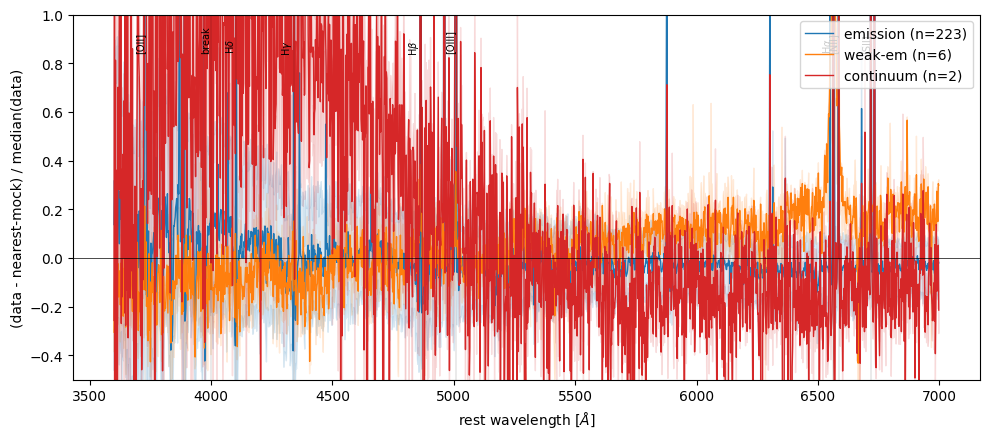

In [11]:
# rest-frame stacked residual: (data - nearest-mock mean) / data-median, per class
nn = np.load("../results/latent_neighbors.npz")
out310 = np.load("../results/outliers310_sample.npz", allow_pickle=True)
cls = dict(zip(out310["target_ids"].astype(np.int64), out310["source_class"]))

wave, zs = nn["wave"], nn["z"]
grid = np.arange(3600.0, 7000.0, 2.0)  # rest-frame grid
stacks = {}
for j, t in enumerate(nn["10latent_out_tids"].astype(np.int64)):
    d, m = nn["spec_data"][j], nn["spec_nbr"][j]
    ok = np.isfinite(d) & np.isfinite(m)
    if ok.sum() < 500:
        continue
    norm = np.median(d[ok])
    r = np.interp(grid, wave[ok] / (1 + zs[j]), ((d - m) / norm)[ok],
                  left=np.nan, right=np.nan)
    stacks.setdefault(cls.get(t, "?"), []).append(r)

fig, ax = plt.subplots(figsize=(10, 4.5))
for c, col in [("emission", "C0"), ("weak-em", "C1"), ("continuum", "C3")]:
    if c not in stacks:
        continue
    S = np.array(stacks[c])
    med = np.nanmedian(S, axis=0)
    lo, hi = np.nanpercentile(S, [25, 75], axis=0)
    ax.plot(grid, med, col, lw=1, label=f"{c} (n={len(S)})")
    ax.fill_between(grid, lo, hi, color=col, alpha=0.15)
for w, name in [(3727, "[OII]"), (4102, r"H$\delta$"), (4341, r"H$\gamma$"),
                (4863, r"H$\beta$"), (5007, "[OIII]"), (6564, r"H$\alpha$"),
                (6585, "[NII]"), (6718, "[SII]"), (4000, "break")]:
    ax.axvline(w, color="k", lw=0.3, alpha=0.4)
    ax.text(w, ax.get_ylim()[1]*0.9 if False else 0.9, name, rotation=90,
            fontsize=7, ha="right", transform=ax.get_xaxis_transform())
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel(r"rest wavelength [$\AA$]")
ax.set_ylabel("(data - nearest-mock) / median(data)")
ax.set_ylim(-0.5, 1.0)
ax.legend(loc="upper right")
plt.tight_layout()